## How Do Player Characteristics Change Over Time in FIFA?

# Introduction

This project examines how male player characteristics change across different years. Our group focuses on understanding how player performance, such as overall rating and key attributes including shooting or passing evolves over time. 

This project also studies how these attributes relate to overall rating, in order to better understand the relative importance of different attributes in shaping overall rating and expain the changing trends over time.

This question is important because it helps us evaluate whether player ratings remain consistent across different year and whether certain types of attributes change more than others over time.



# Data Description

This project uses FIFA player datasets from multiple years, specifically from FIFA 15 to FIFA 22. Each dataset corresponds to one FIFA version, and each row represents one male player in a given year. The datasets contain a large number of observations, ranging from about 15,000 to over 19,000 players per year. For example, FIFA 15 includes 16,155 players, FIFA 16 includes 15,623 players, and FIFA 22 includes 19,239 players. All datasets have 110 variables in each table.

The data includes player identifiers such as sofifa_id, which allows us to track players across different years. It also contains performance-related variables such as overall rating and key attributes including pace or shooting. These variables allow us to analyze how player characteristics change across different years.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

data15=pd.read_csv("2-FIFA/players_15.csv", low_memory=False)
data16=pd.read_csv("2-FIFA/players_16.csv", low_memory=False)
data17=pd.read_csv("2-FIFA/players_17.csv", low_memory=False)
data18=pd.read_csv("2-FIFA/players_18.csv", low_memory=False)
data19=pd.read_csv("2-FIFA/players_19.csv", low_memory=False)
data20=pd.read_csv("2-FIFA/players_20.csv", low_memory=False)
data21=pd.read_csv("2-FIFA/players_21.csv", low_memory=False)
data22=pd.read_csv("2-FIFA/players_22.csv", low_memory=False)

In [3]:
print(data15.shape)
print(data16.shape)
print(data17.shape)
print(data18.shape)
print(data19.shape)
print(data20.shape)
print(data21.shape)
print(data22.shape)


(16155, 110)
(15623, 110)
(17596, 110)
(17954, 110)
(18085, 110)
(18483, 110)
(18944, 110)
(19239, 110)


# Merging Procedures

We combine multiple FIFA player datasets from different years into a single dataset for analysis. First, we add a new column called year to each dataset to indicate the corresponding FIFA version. This allows us to track changes in player characteristics over time. Since all datasets contain the same variables, we merge them by using concatenation. The final merged dataset contains all players from FIFA 15 to FIFA 22, with each row representing one player in a specific year. This combined dataset allows us to analyze trends across different years.

In [4]:
data15["year"] = 2015
data16["year"] = 2016
data17["year"] = 2017
data18["year"] = 2018
data19["year"] = 2019
data20["year"] = 2020
data21["year"] = 2021
data22["year"] = 2022

df = pd.concat([data15, data16, data17, data18, data19, data20, data21, data22], axis=0)

print(df.shape)

(142079, 111)


# Data Cleaning

Before analysis, we perform several data cleaning steps to ensure consistency and reliability. First, we only keep the variables that are relevant to our analysis, such as sofifa_id, year, overall, and key attributes including pace, shooting, passing, dribbling, defending, and physical ability. 

Unnecessary columns are removed to simplify the dataset. Next, we check for missing values in key variables and drop observations with missing values. We also ensure that all selected variables are in the correct data format. Finally, we remove duplicate records if any exist. These steps help ensure that the final dataset is clean and suitable for analyzing trends across years.

In [5]:

cols = ["sofifa_id", "year", "overall","pace", "shooting", "passing","dribbling", "defending", "physic"]

df_clean = df[cols]

df_clean.isnull().sum()
df_clean = df_clean.dropna()
df_clean = df_clean.drop_duplicates()

print(df_clean.shape)
print(df_clean.dtypes)

(126288, 9)
sofifa_id      int64
year           int64
overall        int64
pace         float64
shooting     float64
passing      float64
dribbling    float64
defending    float64
physic       float64
dtype: object


# Main Variables and Descriptive Statistics

The main variables include overall, which represents a player’s overall rating, and several important attributes such as pace, shooting, passing, dribbling, defending, and physical ability. These variables are selected because they reflect different aspects of player performance and are directly related to our research questions on how player characteristics change over time.

To better understand the distribution of these variables, we compute descriptive statistics including the mean, standard deviation, minimum, and maximum values. These statistics provide a general overview of player performance across all years. 

In [5]:
summary = df[["overall", "pace", "shooting", 
              "passing","dribbling", "defending", "physic"]].describe().loc[["mean", "std", "min", "max"]] 
         
print(summary.round(2))

      overall   pace  shooting  passing  dribbling  defending  physic
mean    65.71  67.98     52.19    56.89      62.01      51.05   64.83
std      7.06  11.12     13.94    10.55      10.40      16.69    9.73
min     40.00  21.00     14.00    20.00      22.00      14.00   27.00
max     94.00  97.00     94.00    93.00      96.00      91.00   92.00


# Result 

# Part I: Average Player Ratings Over Time

In [6]:
avg_overall = df.groupby("year")["overall"].mean().reset_index()
avg_overall = avg_overall.sort_values("year")
avg_overall

,year,overall
0,2015,63.830393
1,2016,65.447033
2,2017,66.095533
3,2018,66.244124
4,2019,66.148300
5,2020,66.198885
6,2021,65.677787
7,2022,65.772182


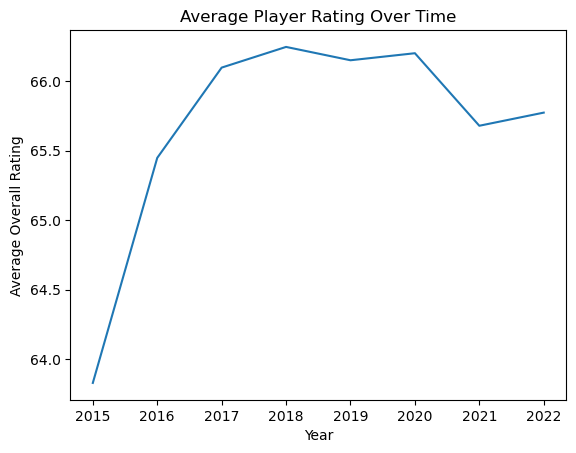

In [7]:
plt.figure()
plt.plot(avg_overall["year"], avg_overall["overall"])
plt.xlabel("Year")
plt.ylabel("Average Overall Rating")
plt.title("Average Player Rating Over Time")
plt.show()

# Explanation

The results show that the average player rating remains relatively stable across different FIFA years. While there are small fluctuations from year to year, there is no obvious upward or downward trend in overall ratings. This suggests that the FIFA rating system is relatively consistent over time, and the average level of player performance does not change dramatically across different years

# Part II: Comparison of Different Attributes Over Time

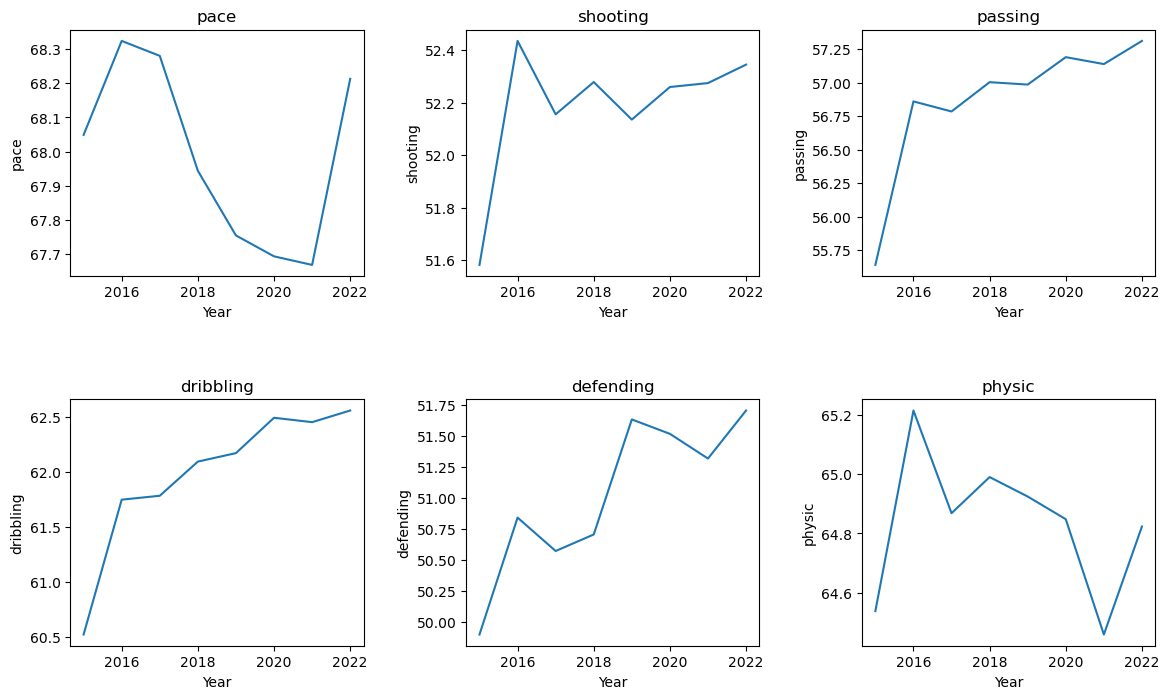

In [8]:
cols = ["pace", "shooting", "passing", "dribbling", "defending", "physic"]

plt.figure(figsize=(14, 8))

for i in range(6):
    plt.subplot(2, 3, i+1)
    avg = df.groupby("year")[cols[i]].mean()
    plt.plot(avg.index, avg.values)
    
    plt.title(cols[i])
    plt.xlabel("Year")
    plt.ylabel(cols[i])

plt.subplots_adjust(hspace=0.5, wspace=0.35)
plt.show()

# Explanation
The six plots show how different player attributes change across years. Overall, most attributes remain relatively stable over time, with only small fluctuations from year to year.

For physical-related attributes, pace shows a slight decrease from around 2017 to 2021, followed by a noticeable increase in 2022. Similarly, physic fluctuates over time without a clear upward or downward trend, suggesting that physical ability remains relatively consistent across years.

For technical attributes, passing and dribbling show a gradual increasing trend over time, indicating that these skills may be rated slightly higher in more recent FIFA versions. Shooting remains fairly stable with minor fluctuations, while defending shows a modest upward trend, especially after 2018.

Overall, these results suggest that different types of attributes evolve differently over time. Technical attributes tend to show slight improvements, while physical attributes are more stable. This supports the idea that not all aspects of player performance change in the same way across years.

predicted_overall = 0.000494730334884291* pace + 0.10887047180384893* shooting + 0.07258281928914362* passing + 0.27800056747025004* dribbling + 0.1191273408848227* defending + 0.25690424843669296* physic + 16.06165036491968


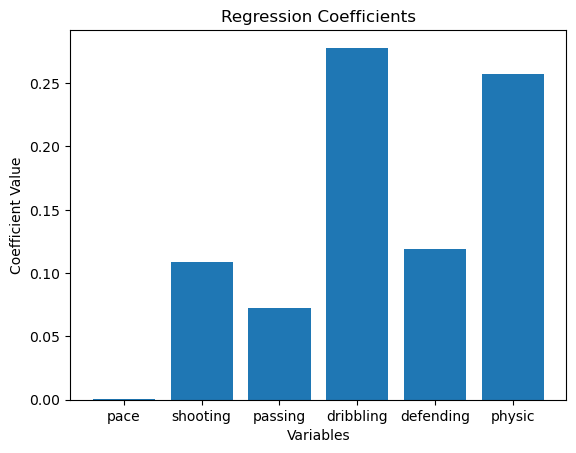

In [14]:
model = smf.ols(formula = "overall ~ pace + shooting + passing + dribbling + defending + physic", data = df_clean)
coeffs = model.fit().params
a = coeffs["pace"]
b = coeffs["shooting"]
c = coeffs["passing"]
d = coeffs["dribbling"]
e = coeffs["defending"]
f = coeffs["physic"]
g = coeffs["Intercept"]
print("predicted_overall = "+ str(a) + "* pace + " + str(b) + "* shooting + " 
      + str(c) + "* passing + " + str(d) + "* dribbling + " + str(e) + "* defending + " 
      + str(f) + "* physic + "+ str(g))

variables = ["pace", "shooting", "passing", "dribbling", "defending", "physic"]
values = [a, b, c, d, e, f]
plt.bar(variables, values)
plt.title("Regression Coefficients")
plt.xlabel("Variables")
plt.ylabel("Coefficient Value")
plt.show()



# Explaination
By using linear regression, we explore how six attributes are correlated with overall rating. 

The plot displays the estimated regression coefficients for the six player attributes used to predict overall rating. Each coefficient represents the expected change in a player’s overall rating associated with a one-unit increase in that attribute while holding other variables constant.The results suggest that pace has the smallest effect on overall rating, with a coefficient of 0.005. In contrast, dribbling and physic have the largest coefficients, 0.278 and 0.257 respectively.

These findings also help explain changes in average overall rating across years. For example, the sudden decline in average overall rating in 2021 may be partly explained by a corresponding drop in the average physic attribute during that year.

Overall, this regression helps us better understand which player attributes are most important in determining overall rating and provides a useful framework for interpreting broader trends in player performance over time.

# Conclusion

The results show that most player attributes remain relatively stable across FIFA years, with only small changes over time. However, different types of attributes behave differently. Technical attributes such as passing and dribbling show slight increases, while physical attributes such as pace and physic fluctuate. This suggests that player characteristics do not evolve in the same way over time.

In addition, the linear regression analysis helps explain how different attributes contribute to overall rating.These finding also helps explain broader trends over time.

One limitation of this analysis is that FIFA ratings are part of a game system and may not fully reflect real-world performance. In addition, we only focus on years and do not consider factors such as age or position. Future work could include these factors to better understand player development.